# SAM Fine-Tuning Experiment Analysis

Comprehensive analysis of SAM (Segment Anything Model) fine-tuning experiments on KITTI-MOTS dataset with different data augmentation configurations and training strategies (Full Fine-Tuning vs LoRA).

**Experiments Analyzed:**
- **FT (Full Fine-Tuning)**: FT_da0, FT_da1, FT_da2, FT_da3 (different data augmentation levels 0-3)
- **LoRA (Low-Rank Adaptation)**: LORA_da0, LORA_da1 (efficient adapter-based training)
- **Baseline**: Pre-trained model without fine-tuning (reference performance)

In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

EXPERIMENT_NAMES = {
    'FT_da0': 'FT Profile 0 (No DA)', 'FT_da1': 'FT Profile 1 (Photometric)',
    'FT_da2': 'FT Profile 2 (Geometric)', 'FT_da3': 'FT Profile 3 (Combined Extended)',
    'LORA_da0': 'LoRA Profile 0 (No DA)', 'LORA_da1': 'LoRA Profile 1 (Photometric)',
    'BASELINE': 'Pretrained'
}

COLORS_MAP = {'FT': "#086170", 'LORA': '#4ECDC4', 'BASELINE': "#B8ECE3"}

def get_display_name(exp_id):
    return EXPERIMENT_NAMES.get(exp_id, exp_id)

with open(Path('sam_log_metrics.json'), 'r') as f:
    data = json.load(f)

print(f"✓ Loaded {len(data['experiments'])} experiments")
print(f"Baseline: {data['baseline']['name']}")

✓ Loaded 6 experiments
Baseline: BASE_pretrained


## 4. COCO Metrics Comprehensive Comparison

Detailed comparison of precision and recall metrics across all experiments.

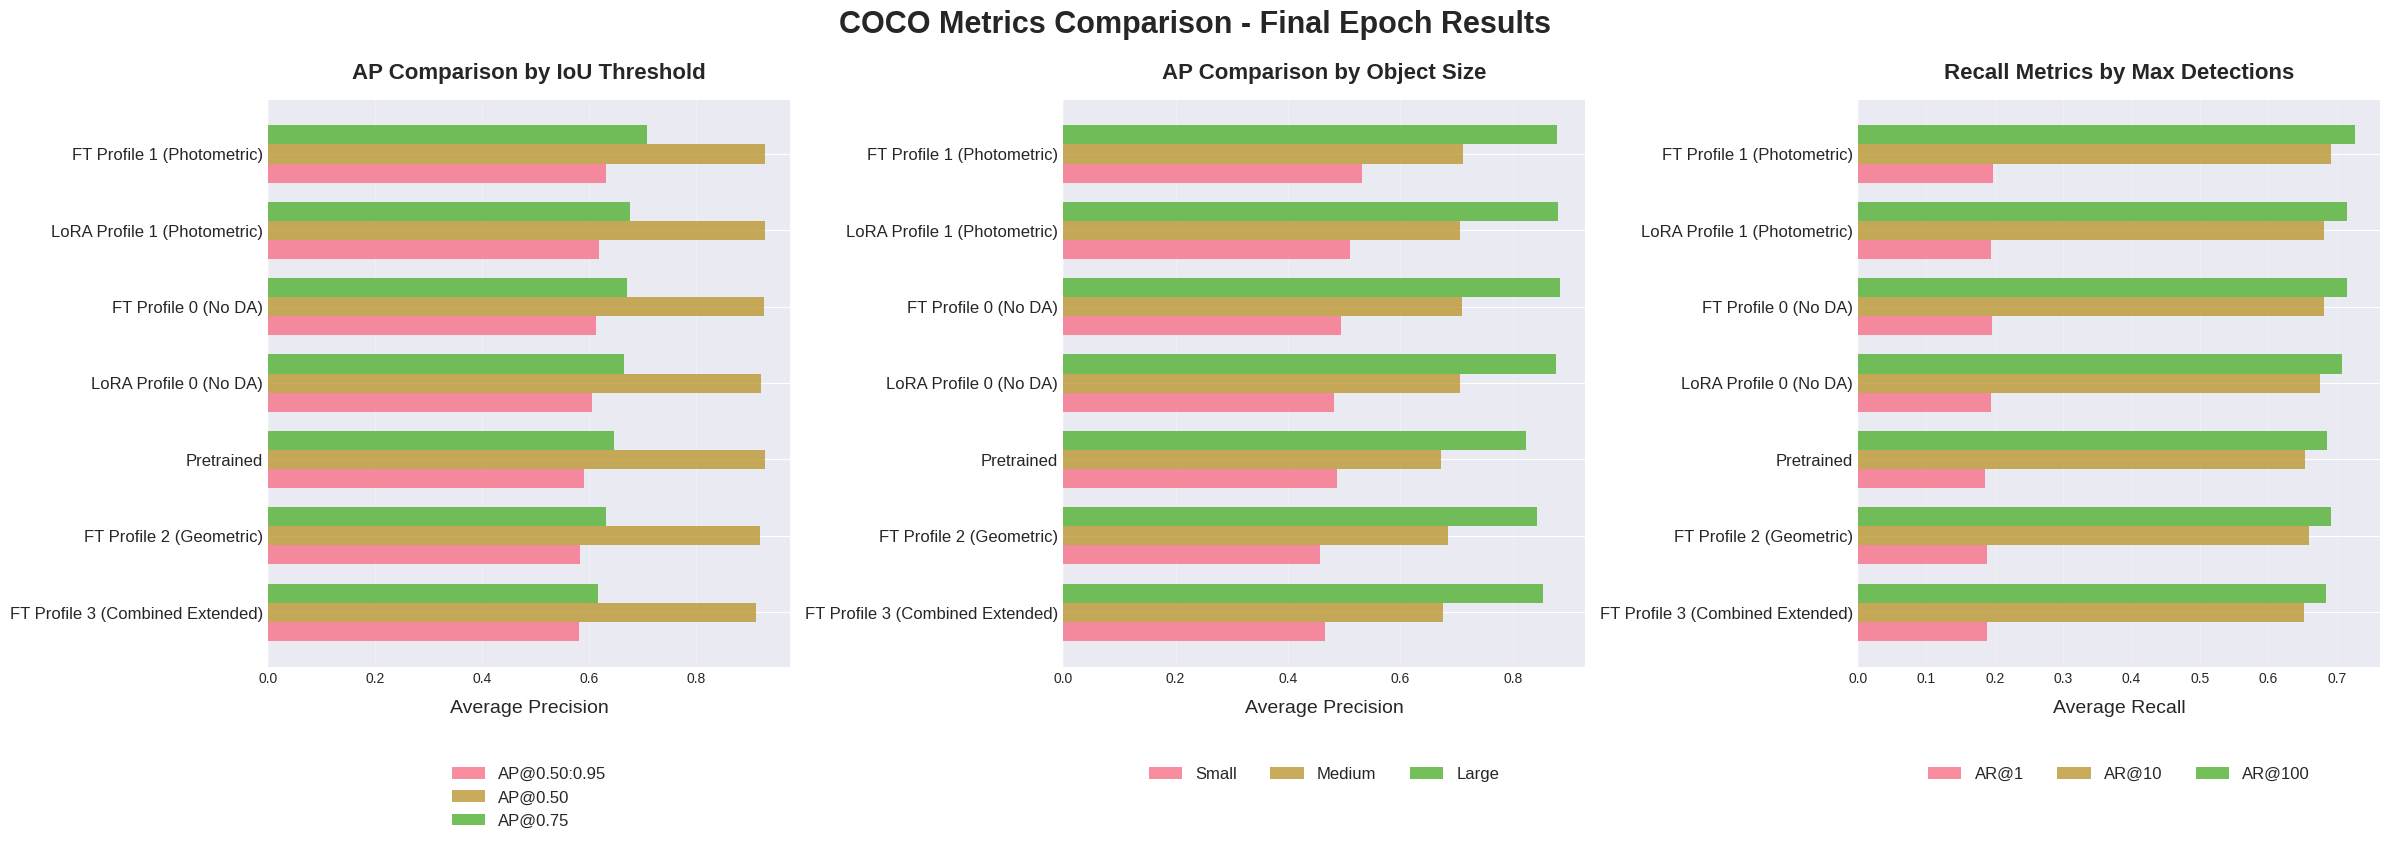

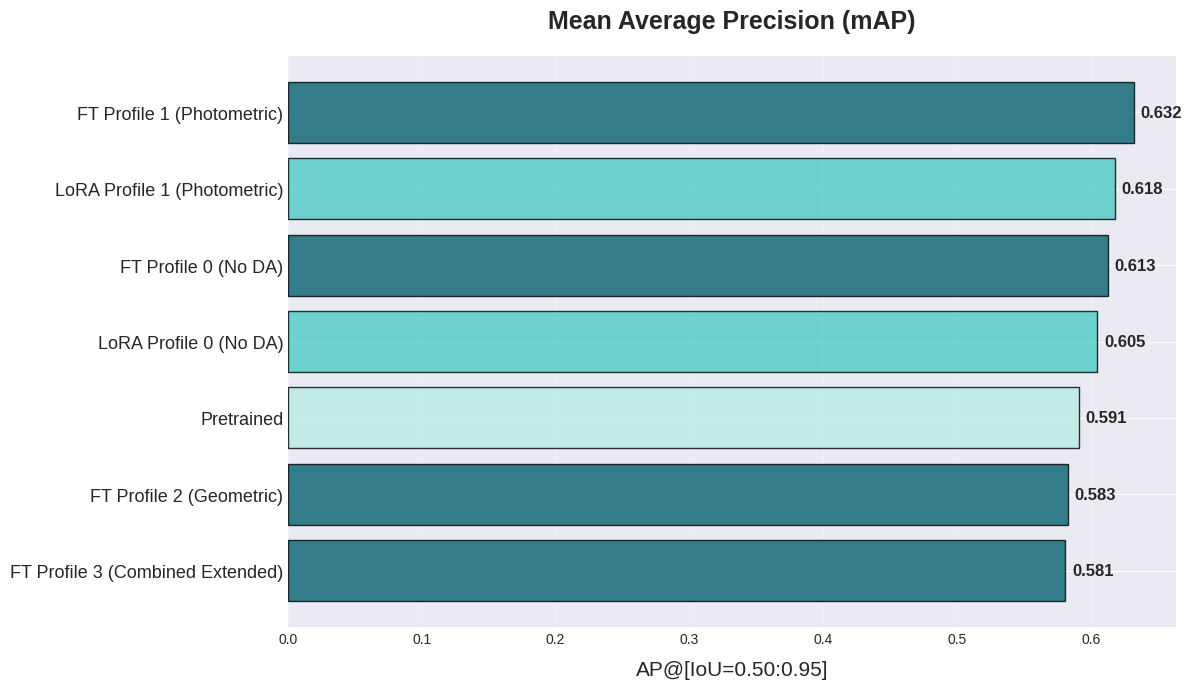

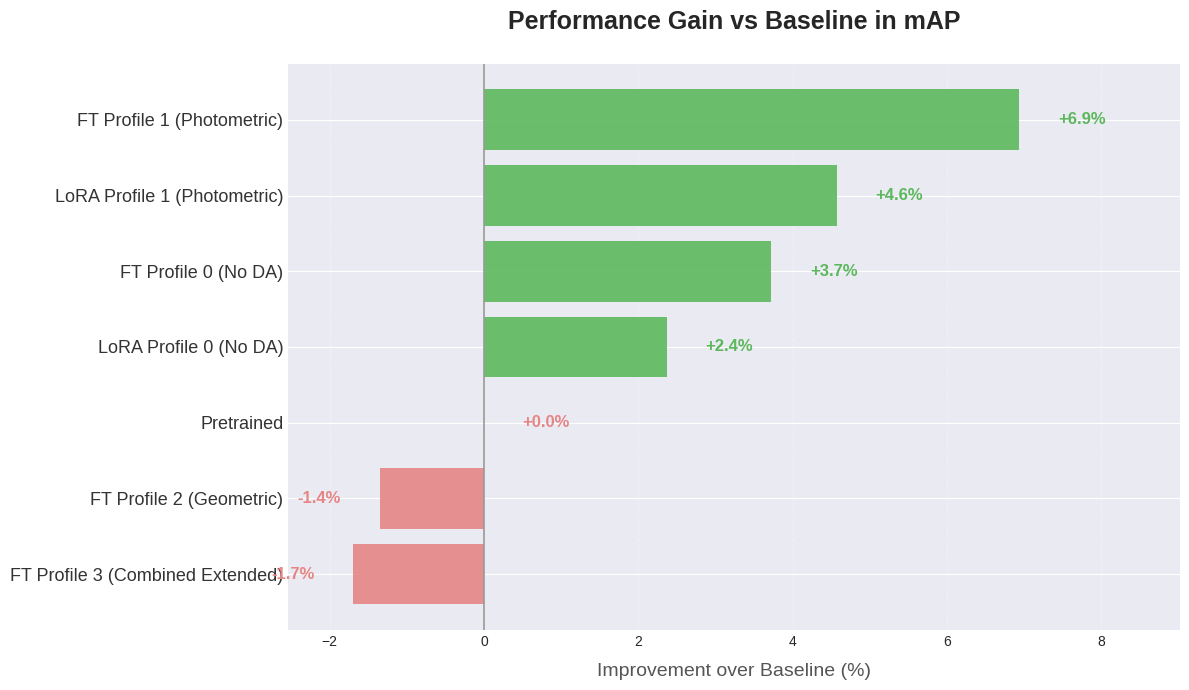

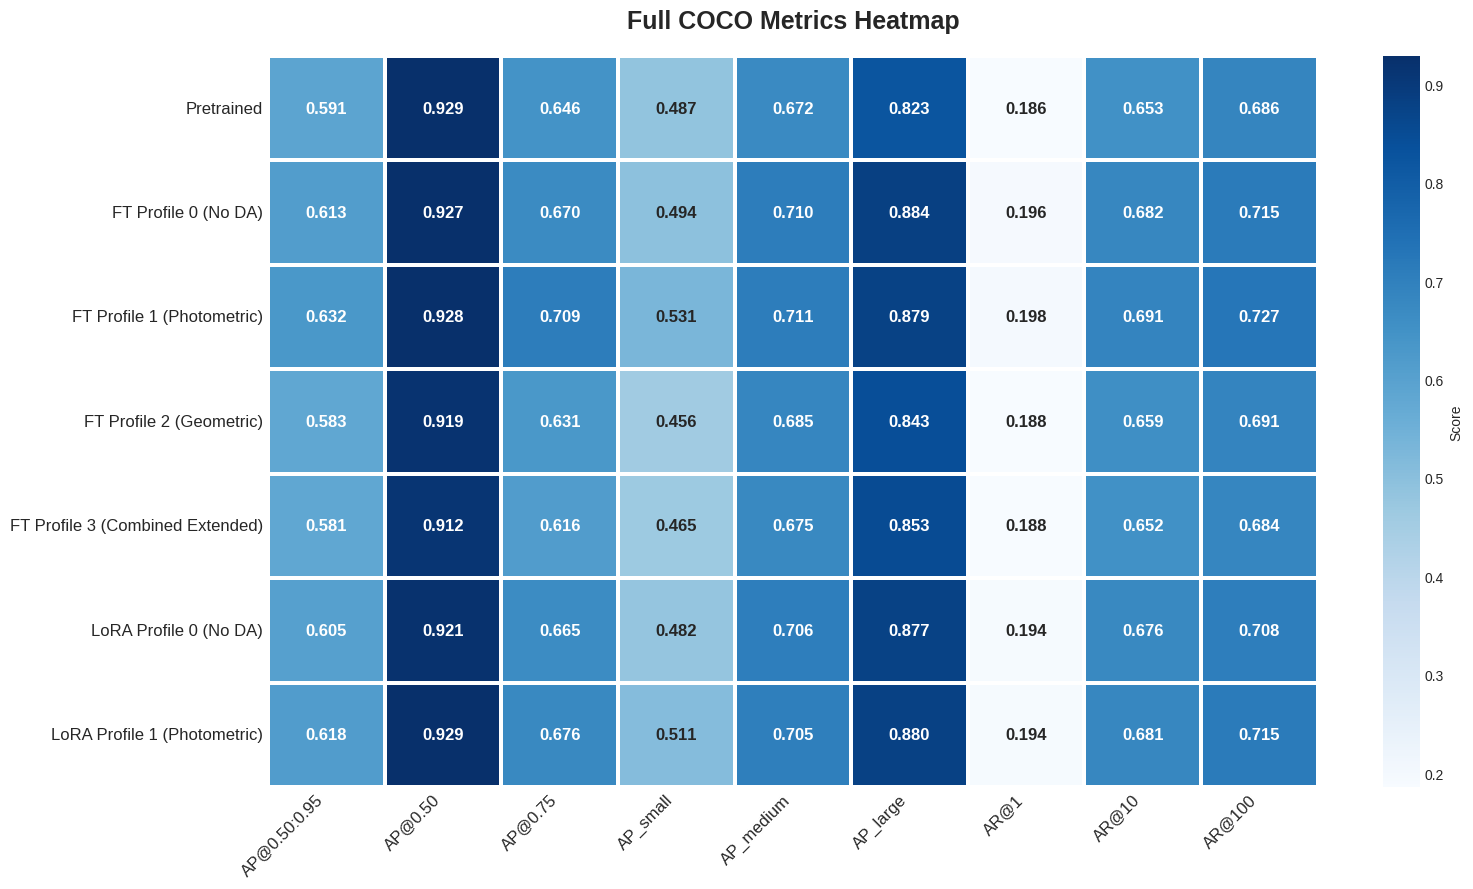

In [7]:
final_metrics_list = []
for exp_name, exp_data in data['experiments'].items():
    if len(exp_data['epochs']) > 0:
        final_epoch = exp_data['epochs'][-1]
        metrics = final_epoch['coco_metrics']
        final_metrics_list.append({
            'Experiment': exp_name, 'Display_Name': get_display_name(exp_name), 'Group': exp_data['group'],
            'AP@0.50:0.95': metrics['AP@[IoU=0.50:0.95|area=all|maxDets=100]'],
            'AP@0.50': metrics['AP@[IoU=0.50|area=all|maxDets=100]'],
            'AP@0.75': metrics['AP@[IoU=0.75|area=all|maxDets=100]'],
            'AP_small': metrics['AP@[IoU=0.50:0.95|area=small|maxDets=100]'],
            'AP_medium': metrics['AP@[IoU=0.50:0.95|area=medium|maxDets=100]'],
            'AP_large': metrics['AP@[IoU=0.50:0.95|area=large|maxDets=100]'],
            'AR@1': metrics['AR@[IoU=0.50:0.95|area=all|maxDets=1]'],
            'AR@10': metrics['AR@[IoU=0.50:0.95|area=all|maxDets=10]'],
            'AR@100': metrics['AR@[IoU=0.50:0.95|area=all|maxDets=100]'],
        })

final_metrics_list.append({
    'Experiment': 'BASELINE', 'Display_Name': get_display_name('BASELINE'), 'Group': 'BASELINE',
    'AP@0.50:0.95': data['baseline']['coco_metrics']['AP@[IoU=0.50:0.95|area=all|maxDets=100]'],
    'AP@0.50': data['baseline']['coco_metrics']['AP@[IoU=0.50|area=all|maxDets=100]'],
    'AP@0.75': data['baseline']['coco_metrics']['AP@[IoU=0.75|area=all|maxDets=100]'],
    'AP_small': data['baseline']['coco_metrics']['AP@[IoU=0.50:0.95|area=small|maxDets=100]'],
    'AP_medium': data['baseline']['coco_metrics']['AP@[IoU=0.50:0.95|area=medium|maxDets=100]'],
    'AP_large': data['baseline']['coco_metrics']['AP@[IoU=0.50:0.95|area=large|maxDets=100]'],
    'AR@1': data['baseline']['coco_metrics']['AR@[IoU=0.50:0.95|area=all|maxDets=1]'],
    'AR@10': data['baseline']['coco_metrics']['AR@[IoU=0.50:0.95|area=all|maxDets=10]'],
    'AR@100': data['baseline']['coco_metrics']['AR@[IoU=0.50:0.95|area=all|maxDets=100]'],
})

metrics_df = pd.DataFrame(final_metrics_list).sort_values('AP@0.50:0.95', ascending=False)
plot_df = metrics_df.sort_values('AP@0.50:0.95', ascending=True)
display_names = plot_df['Display_Name'].values
x_pos = np.arange(len(display_names))

fig1, axes = plt.subplots(1, 3, figsize=(24, 9))
fig1.suptitle('COCO Metrics Comparison - Final Epoch Results', fontsize=22, fontweight='bold', y=0.98)

ax = axes[0]
width = 0.25
ax.barh(x_pos - width, plot_df['AP@0.50:0.95'], width, label='AP@0.50:0.95', alpha=0.8)
ax.barh(x_pos, plot_df['AP@0.50'], width, label='AP@0.50', alpha=0.8)
ax.barh(x_pos + width, plot_df['AP@0.75'], width, label='AP@0.75', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(display_names, fontsize=12)
ax.set_xlabel('Average Precision', fontsize=14, labelpad=10)
ax.set_title('AP Comparison by IoU Threshold', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

ax = axes[1]
width = 0.25
ax.barh(x_pos - width, plot_df['AP_small'], width, label='Small', alpha=0.8)
ax.barh(x_pos, plot_df['AP_medium'], width, label='Medium', alpha=0.8)
ax.barh(x_pos + width, plot_df['AP_large'], width, label='Large', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(display_names, fontsize=12)
ax.set_xlabel('Average Precision', fontsize=14, labelpad=10)
ax.set_title('AP Comparison by Object Size', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

ax = axes[2]
width = 0.25
ax.barh(x_pos - width, plot_df['AR@1'], width, label='AR@1', alpha=0.8)
ax.barh(x_pos, plot_df['AR@10'], width, label='AR@10', alpha=0.8)
ax.barh(x_pos + width, plot_df['AR@100'], width, label='AR@100', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(display_names, fontsize=12)
ax.set_xlabel('Average Recall', fontsize=14, labelpad=10)
ax.set_title('Recall Metrics by Max Detections', fontsize=16, fontweight='bold', pad=15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=12)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, top=0.88)
plt.show()

fig2, ax = plt.subplots(figsize=(12, 7))
colors = [COLORS_MAP[g] for g in plot_df['Group'].values]
bars = ax.barh(x_pos, plot_df['AP@0.50:0.95'], color=colors, alpha=0.8, edgecolor='black')
ax.set_yticks(x_pos)
ax.set_yticklabels(display_names, fontsize=13)
ax.set_xlabel('AP@[IoU=0.50:0.95]', fontsize=15, labelpad=10)
ax.set_title('Mean Average Precision (mAP)', fontsize=18, fontweight='bold', pad=20)
ax.grid(True, axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.005, bar.get_y() + bar.get_height()/2., f'{width:.3f}',
            ha='left', va='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

fig3, ax = plt.subplots(figsize=(12, 7))
baseline_ap = metrics_df[metrics_df['Experiment'] == 'BASELINE']['AP@0.50:0.95'].values[0]
improvement = ((plot_df['AP@0.50:0.95'] - baseline_ap) / baseline_ap * 100)
colors_imp = ['#5cb85c' if x > 0 else '#e68585' for x in improvement]
bars = ax.barh(x_pos, improvement, color=colors_imp, alpha=0.9, edgecolor='none')
min_val, max_val = min(improvement), max(improvement)
ax.set_xlim(min_val * 1.5, max_val * 1.3)
ax.set_yticks(x_pos)
ax.set_yticklabels(display_names, fontsize=13, color='#333333')
ax.set_xlabel('Improvement over Baseline (%)', fontsize=14, color='#555555', labelpad=10)
ax.set_title('Performance Gain vs Baseline in mAP', fontsize=18, fontweight='bold', pad=25)
ax.axvline(x=0, color='#999999', linestyle='-', linewidth=1.2)
ax.grid(True, axis='x', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for i, bar in enumerate(bars):
    width = bar.get_width()
    text_color = '#5cb85c' if width > 0 else '#e68585'
    offset = 0.5 if width >= 0 else -0.5
    alignment = 'left' if width >= 0 else 'right'
    ax.text(width + offset, bar.get_y() + bar.get_height()/2., f'{width:+.1f}%',
            ha=alignment, va='center', fontsize=12, fontweight='bold', color=text_color)
plt.tight_layout()
plt.show()

def custom_sort_key(name):
    if 'Pretrained' in name or 'BASELINE' in name: return 0
    elif name.startswith('FT'): return 1
    elif name.startswith('LoRA'): return 2
    return 3

heatmap_df = plot_df.copy()
heatmap_df['Sort_Order'] = heatmap_df['Display_Name'].apply(custom_sort_key)
heatmap_df = heatmap_df.sort_values(by=['Sort_Order', 'Display_Name'])

fig4, ax = plt.subplots(figsize=(16, 9))
heatmap_data = heatmap_df.set_index('Display_Name')[['AP@0.50:0.95', 'AP@0.50', 'AP@0.75', 'AP_small', 'AP_medium', 'AP_large', 'AR@1', 'AR@10', 'AR@100']]
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="Blues", linewidths=1.5, linecolor='white',
            cbar_kws={'label': 'Score'}, annot_kws={"size": 12, "weight": "bold"}, ax=ax)
ax.set_title('Full COCO Metrics Heatmap', fontsize=18, fontweight='bold', pad=20)
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()